# CS-4063 — NLP Assignment 3: Transformer + RAG
## FAST NUCES — Transformer-based Review Understanding with RAG-Enhanced Explanation Generation

### Execution Instructions
1. Place the three `.gz` dataset files (`sports_json.gz`, `beauty_json.gz`, `cellphones_json.gz`) in the same directory as this notebook, or adjust `DATA_FILES` paths below.
2. Run all cells top-to-bottom via **Kernel → Restart & Run All**.
3. Trained weights will be saved in `models/`, embeddings in `results/`, plots and metrics in `results/`.
4. A GPU is strongly recommended (CUDA or MPS). On CPU, reduce `NUM_EPOCHS` and `BATCH_SIZE`.

### Directory Layout
```
.
├── i23XXXX-NLP-Assignment3.ipynb   ← this notebook
├── sports_json.gz
├── beauty_json.gz
├── cellphones_json.gz
├── models/                         ← saved weights (auto-created)
└── results/                        ← embeddings, metrics, plots (auto-created)
```

---
## 0. Imports & Global Configuration

In [4]:
import os, gzip, json, math, random, re, time, warnings
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
# GLOBAL CONFIG  — adjust these to tune the system
# ──────────────────────────────────────────────────────────────
SEED            = 42
REVIEWS_PER_CAT = 12_000   # 10k-15k per category as required
MAX_SEQ_LEN     = 128      # max tokens for encoder input
VOCAB_SIZE      = 20_000   # vocabulary size (built from train only)
EMBED_DIM       = 128      # embedding / model dimension
NUM_HEADS       = 4        # attention heads
FF_DIM          = 256      # feed-forward hidden size
NUM_ENC_LAYERS  = 2        # encoder transformer blocks
NUM_DEC_LAYERS  = 2        # decoder transformer blocks
DROPOUT         = 0.1
BATCH_SIZE      = 64
NUM_EPOCHS      = 8        # encoder training epochs
LR              = 3e-4
TOP_K           = 3        # retrieved neighbours for RAG
MAX_GEN_LEN     = 40       # max tokens to generate
DEC_EPOCHS      = 6        # decoder training epochs

DATA_FILES = [
    ('sports',      '/content/sports.json.gz'),
    ('beauty',      '/content/beauty.json.gz'),
    ('cellphones',  '/content/cellphones.json.gz'),
]

Path('models').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
## 1. Dataset Loading & Preprocessing

**Design choices:**
- Load 10k–15k reviews per category from the raw `.gz` JSONL files.
- Stratify by rating so all 5 star levels are proportionally represented.
- Text cleaning: lowercase, strip HTML, collapse whitespace, remove non-alphanumeric.
- Sentiment mapping: 1-2 → 0 (Negative), 3 → 1 (Neutral), 4-5 → 2 (Positive).
- **Derived feature:** review length bucket — short (≤30 tokens) → 0, medium (31-80) → 1, long (>80) → 2. Justified because length correlates with information density and can be predicted from text at training time (model must learn to count/structure), and it provides a useful auxiliary signal for the encoder.
- Vocabulary built **only** from training tokens.
- Padding/truncation to `MAX_SEQ_LEN`.

In [5]:
# ── 1.1 Text cleaning ──────────────────────────────────────────
def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags, collapse whitespace, keep alphanumeric."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'[^a-z0-9\s]', ' ', text)      # keep alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

def simple_tokenize(text: str) -> List[str]:
    return text.split()

def rating_to_sentiment(rating: float) -> int:
    if rating <= 2: return 0   # Negative
    if rating == 3: return 1   # Neutral
    return 2                   # Positive

SENTIMENT_NAMES = ['Negative', 'Neutral', 'Positive']
LENGTH_NAMES    = ['Short', 'Medium', 'Long']

def length_bucket(tokens: List[str]) -> int:
    n = len(tokens)
    if n <= 30: return 0
    if n <= 80: return 1
    return 2

In [6]:
# ── 1.2 Load raw data ──────────────────────────────────────────
def load_reviews(path: str, n: int, category: str) -> List[Dict]:
    records = []
    with gzip.open(path, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                obj = json.loads(line)
                text = obj.get('reviewText', '').strip()
                rating = float(obj.get('overall', 0))
                if text and 1 <= rating <= 5:
                    records.append({'text': text, 'rating': rating, 'category': category})
                    if len(records) >= n * 3:  # oversample, stratify later
                        break
            except:
                continue
    return records

def stratified_sample(records: List[Dict], n: int) -> List[Dict]:
    """Sample n reviews with roughly equal representation across ratings 1-5."""
    buckets = {i: [] for i in range(1, 6)}
    for r in records:
        buckets[int(r['rating'])].append(r)
    per_bucket = n // 5
    sampled = []
    for b in buckets.values():
        random.shuffle(b)
        sampled.extend(b[:per_bucket])
    random.shuffle(sampled)
    return sampled[:n]

all_records = []
for cat, path in DATA_FILES:
    raw = load_reviews(path, REVIEWS_PER_CAT, cat)
    sampled = stratified_sample(raw, REVIEWS_PER_CAT)
    all_records.extend(sampled)
    print(f'{cat}: loaded {len(sampled)} reviews')

random.shuffle(all_records)
print(f'\nTotal reviews: {len(all_records)}')

sports: loaded 9486 reviews
beauty: loaded 11587 reviews
cellphones: loaded 12000 reviews

Total reviews: 33073


In [7]:
# ── 1.3 Clean & tokenize, compute labels ──────────────────────
for r in all_records:
    tokens = simple_tokenize(clean_text(r['text']))
    r['tokens']    = tokens
    r['sentiment'] = rating_to_sentiment(r['rating'])
    r['len_label'] = length_bucket(tokens)

# ── 1.4 Train / Val / Test split 70/15/15 ────────────────────
N = len(all_records)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
train_data = all_records[:n_train]
val_data   = all_records[n_train:n_train+n_val]
test_data  = all_records[n_train+n_val:]
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Train: 23151 | Val: 4960 | Test: 4962


In [8]:
# ── 1.5 Build vocabulary from TRAINING data only ──────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

counter = Counter()
for r in train_data:
    counter.update(r['tokens'])

vocab_words = [w for w, _ in counter.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS))]
vocab = {tok: i for i, tok in enumerate(SPECIAL_TOKENS + vocab_words)}
inv_vocab = {i: w for w, i in vocab.items()}

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]
BOS_IDX = vocab[BOS_TOKEN]
EOS_IDX = vocab[EOS_TOKEN]
ACTUAL_VOCAB = len(vocab)
print(f'Vocabulary size: {ACTUAL_VOCAB}')

def encode(tokens: List[str], max_len: int) -> Tuple[List[int], int]:
    """Convert tokens to ids with truncation & padding. Returns (ids, length)."""
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    length = len(ids)
    ids = ids + [PAD_IDX] * (max_len - length)
    return ids, length

def decode(ids: List[int]) -> str:
    words = []
    for i in ids:
        if i == EOS_IDX: break
        if i not in (PAD_IDX, BOS_IDX):
            words.append(inv_vocab.get(i, UNK_TOKEN))
    return ' '.join(words)

Vocabulary size: 20000


In [18]:
# ── 1.6 PyTorch Datasets ──────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, records: List[Dict], max_len: int):
        self.records = records   # keep for text access outside DataLoader
        self.data = []
        for r in records:
            ids, length = encode(r['tokens'], max_len)
            self.data.append({
                'ids':       torch.tensor(ids,            dtype=torch.long),
                'mask':      torch.tensor([1]*length + [0]*(max_len-length), dtype=torch.bool),
                'sentiment': torch.tensor(r['sentiment'], dtype=torch.long),
                'len_label': torch.tensor(r['len_label'], dtype=torch.long),
                # NO 'text' or 'tokens' — raw strings/lists break default_collate
            })

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

train_ds = ReviewDataset(train_data, MAX_SEQ_LEN)
val_ds   = ReviewDataset(val_data,   MAX_SEQ_LEN)
test_ds  = ReviewDataset(test_data,  MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('Datasets ready.')

Datasets ready.


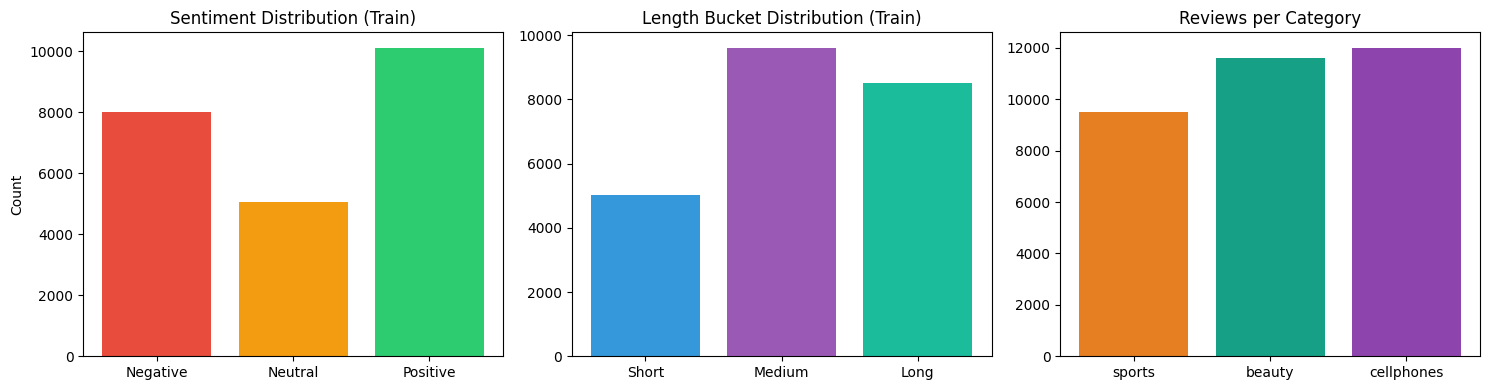

Plot saved.


In [19]:
# ── 1.7 Distribution plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sentiments = [r['sentiment'] for r in train_data]
axes[0].bar(SENTIMENT_NAMES, [sentiments.count(i) for i in range(3)], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Sentiment Distribution (Train)'); axes[0].set_ylabel('Count')

lens = [r['len_label'] for r in train_data]
axes[1].bar(LENGTH_NAMES, [lens.count(i) for i in range(3)], color=['#3498db','#9b59b6','#1abc9c'])
axes[1].set_title('Length Bucket Distribution (Train)')

cats = [r['category'] for r in all_records]
cat_names = list(dict.fromkeys(cats))
axes[2].bar(cat_names, [cats.count(c) for c in cat_names], color=['#e67e22','#16a085','#8e44ad'])
axes[2].set_title('Reviews per Category')

plt.tight_layout()
plt.savefig('results/data_distribution.png', dpi=150)
plt.show()
print('Plot saved.')